
# 🛒 Walmart Retail Sales Data

## Objective of This Session
- Understand real retail sales data
- Learn core Pandas concepts step-by-step
- Understand WHY we use each function
- Visualize insights using Matplotlib and Seaborn



## 🌍 Why Walmart Retail Data Matters in Real Life

Retail companies use data to:
- Measure total revenue
- Identify top-performing stores
- Analyze seasonal demand
- Understand holiday impact
- Make strategic pricing & inventory decisions

Before building predictive models, companies FIRST explore the data.
This step is called **Exploratory Data Analysis (EDA)**.



## ⬇️ How to Download the Dataset
1. Visit the Kaggle Walmart Sales dataset page.
2. Download the ZIP file.
3. Extract it.
4. Place `Walmart.csv` in the same folder as this notebook.



## 📦 Import Required Libraries

We will use only:
- Pandas → Data manipulation
- Matplotlib → Basic visualization
- Seaborn → Advanced visualization


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')



## 📂 Load the Dataset

We read the CSV file into a Pandas DataFrame.

Think of a DataFrame as an Excel sheet inside Python.


In [2]:

df = pd.read_csv('Walmart.csv')
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106



## 🔎 Understanding the Structure (Pandas Basics)

Before analysis, we must understand:
- How many rows?
- How many columns?
- What are the data types?
- Any missing values?


In [3]:
df.shape

(6435, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [6]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


# 📊 Understanding groupby()

### What is groupby()?
`groupby()` is used when we want to:
- Split data into groups
- Apply a calculation (like mean, sum, count)
- Combine results

This is called the Split–Apply–Combine strategy.



### Why do we need groupby() in retail industry?

Retail analysts ask questions like:
- What is the total revenue per store?
- What is the average sales during holidays?
- Which store performs best?

To answer these, we must group similar rows together.



## 📊 Applying groupby() to Our Walmart Data

### Industry Question:
Which store generates highest total revenue?


In [7]:

df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head()


Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64


### Industry Question:
Do holidays increase average weekly sales?


In [8]:

df.groupby('Holiday_Flag')['Weekly_Sales'].mean()


Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64


# 📈 Matplotlib – Basic Visualization

### Why do we visualize?
Because numbers alone are hard to interpret.
Charts help us detect patterns quickly.



# Question 1:
How do total weekly sales change over time?

To answer this, we use a Line Plot.

Why line plot?
- Time series data
- Shows trend clearly


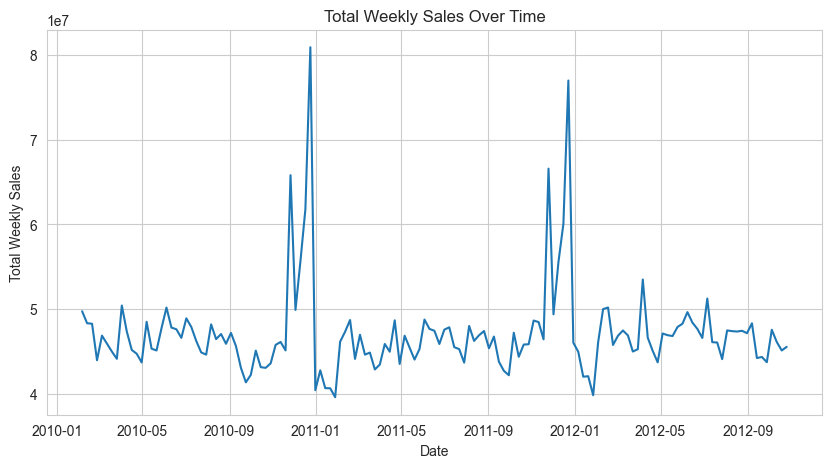

In [10]:

df['Date'] = pd.to_datetime(df['Date'] , format='%d-%m-%Y')
weekly_trend = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(weekly_trend.index, weekly_trend.values)
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.show()



Interpretation:

- Upward trend → Growth
- Spikes → Holiday or promotion effect
- Downward trend → Demand slowdown



# Question 2:
Which stores generate the highest total revenue?


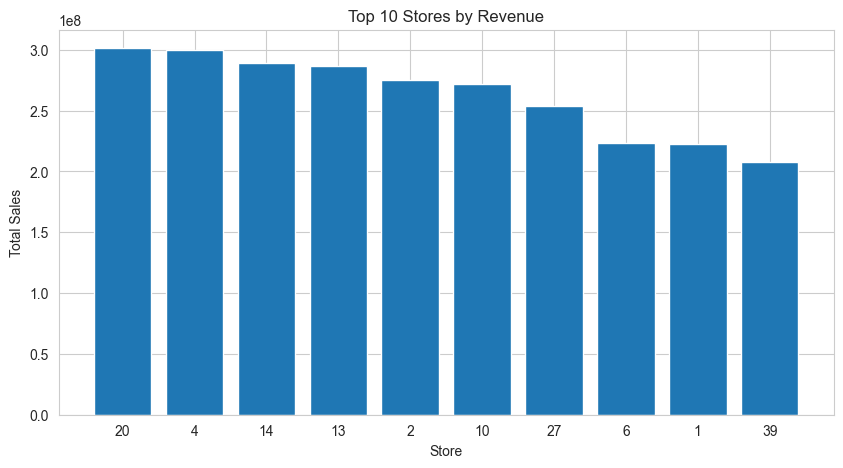

In [11]:

store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(store_sales.index.astype(str), store_sales.values)
plt.title("Top 10 Stores by Revenue")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()



Interpretation:

Higher bar → Higher revenue.
Helps management identify top-performing locations.



# Question 3:
How are weekly sales distributed?


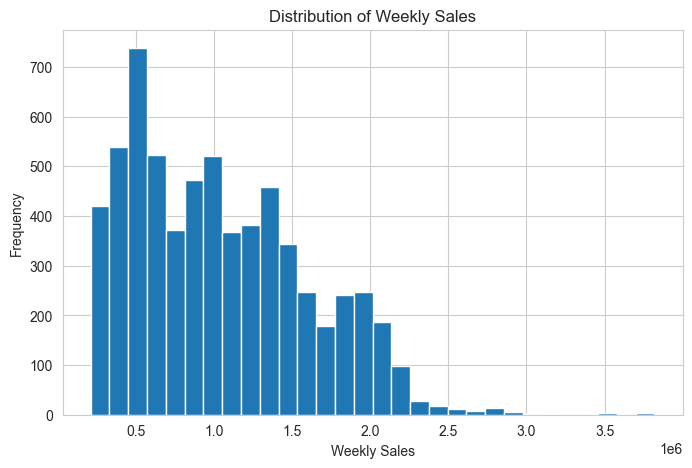

In [12]:

plt.figure(figsize=(8,5))
plt.hist(df['Weekly_Sales'], bins=30)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()



# 📊 Seaborn – Advanced Visualization

Seaborn builds on matplotlib and provides:

- Statistical plots
- Cleaner design
- Built-in aggregation



## SEABORN PLOT 1 — Boxplot

### Question:
Do holiday weeks show different sales distribution?


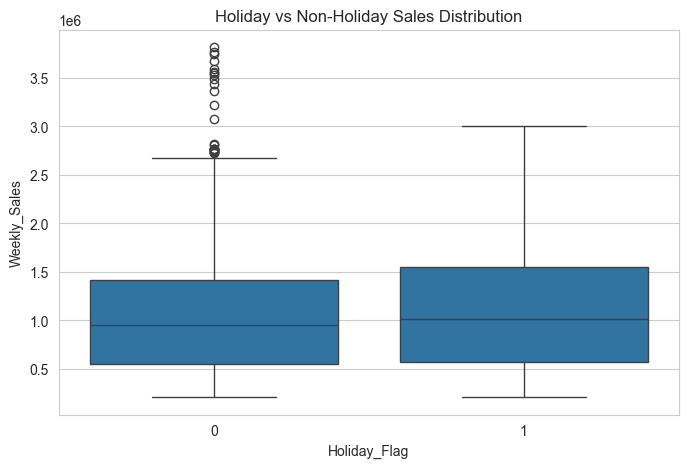

In [13]:

plt.figure(figsize=(8,5))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.title("Holiday vs Non-Holiday Sales Distribution")
plt.show()



Boxplot shows:
- Median
- Spread
- Outliers

If holiday median is higher → Promotions are effective.



## SEABORN PLOT 2 — Regression Plot

### Question:
Does unemployment affect weekly sales?


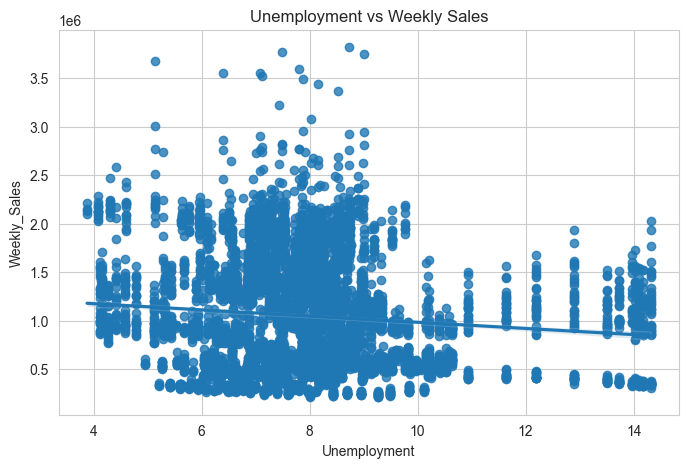

In [14]:

plt.figure(figsize=(8,5))
sns.regplot(x='Unemployment', y='Weekly_Sales', data=df)
plt.title("Unemployment vs Weekly Sales")
plt.show()



If slope is downward:
Higher unemployment → Lower sales.



## SEABORN PLOT 3 — Correlation Heatmap

### Question:
Which economic variables strongly relate to sales?


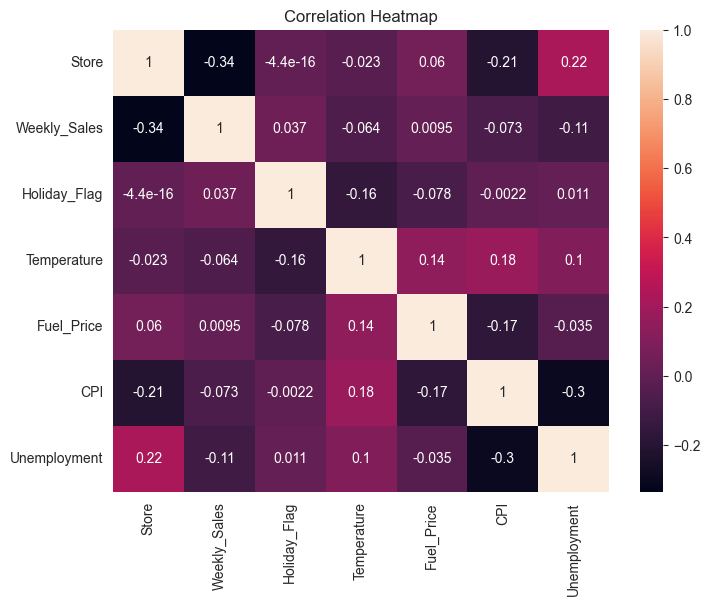

In [15]:

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()



Heatmap shows strength of relationships.

Closer to +1 → Strong positive relationship  
Closer to -1 → Strong negative relationship  
